In [ ]:
# Install required libraries
!pip install shap joblib
!pip install mlflow

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import mlflow
import mlflow.sklearn
import shap
import joblib

In [ ]:
# Load Data
elec_data = loadmat('dataset_elec.mat')
amb_data = loadmat('dataset_amb.mat')

vdc1 = elec_data['vdc1'].flatten()
vdc2 = elec_data['vdc2'].flatten()
idc1 = elec_data['idc1'].flatten()
idc2 = elec_data['idc2'].flatten()

irr = amb_data['irr'].flatten()
pvt = amb_data['pvt'].flatten()
f_nv = amb_data['f_nv'].flatten()

# Create DataFrame
df = pd.DataFrame({
    'vdc1': vdc1,
    'vdc2': vdc2,
    'idc1': idc1,
    'idc2': idc2,
    'irradiance': irr,
    'temperature': pvt,
    'fault_label': f_nv
})

In [ ]:
# Filter out unwanted labels
df = df[df['fault_label'] != 2].copy()

# Feature Engineering
df['power_string1'] = df['vdc1'] * df['idc1']
df['power_string2'] = df['vdc2'] * df['idc2']
df['total_power'] = df['power_string1'] + df['power_string2']
df['voltage_ratio'] = df['vdc1'] / df['vdc2']
df['current_ratio'] = df['idc1'] / df['idc2']

# Map fault names
fault_names = {0: 'Normal Operation', 1: 'Short-Circuit', 3: 'Open Circuit', 4: 'Shadowing'}
df['fault_label'] = df['fault_label'].map(fault_names)

In [ ]:
# Prepare Features and Labels
X = df.drop(['fault_label'], axis=1)
y = df['fault_label']

In [ ]:
# One-hot encode labels for multiclass metrics
ohe = OneHotEncoder()
y_encoded = ohe.fit_transform(y.values.reshape(-1, 1)).toarray()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# Compute class weights to handle imbalance
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {'Normal Operation': np.float64(0.2931015301866836), 'Open Circuit': np.float64(56.585443037974684), 'Shadowing': np.float64(1.808509474131013), 'Short-Circuit': np.float64(56.82126484684309)}


In [ ]:
mlflow.set_experiment("PV_Fault_Detection_RF")

with mlflow.start_run(run_name="RandomForest_v1"):

    # Log parameters
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", None)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("random_state", 42)

    # Train Random Forest
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight=class_weights,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    # Predict
    y_pred = rf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", acc)

    # Log other metrics individually
    from sklearn.metrics import precision_score, recall_score, f1_score
    mlflow.log_metric("precision_macro", precision_score(y_test, y_pred, average='macro'))
    mlflow.log_metric("recall_macro", recall_score(y_test, y_pred, average='macro'))
    mlflow.log_metric("f1_macro", f1_score(y_test, y_pred, average='macro'))

    # Log the model
    mlflow.sklearn.log_model(rf, artifact_path="rf_model")

    print(f"Run completed. Test Accuracy: {acc}")

2026/02/09 11:30:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/09 11:30:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/09 11:30:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/09 11:30:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/09 11:30:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/09 11:30:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/09 11:30:35 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/09 11:30:35 INFO mlflow.store.db.utils: Updating database tables
2026/02/09 11:30:35 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/09 11:30:35 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/09 11:30:35 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/02/09 11:3

Run completed. Test Accuracy: 0.9991492045796264


In [ ]:
# Predictions
y_pred = rf.predict(X_test)

In [ ]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9991492045796264

Classification Report:
                   precision    recall  f1-score   support

Normal Operation       1.00      1.00      1.00    232587
    Open Circuit       1.00      1.00      1.00      1205
       Shadowing       1.00      1.00      1.00     37694
   Short-Circuit       1.00      0.99      1.00      1200

        accuracy                           1.00    272686
       macro avg       1.00      1.00      1.00    272686
    weighted avg       1.00      1.00      1.00    272686



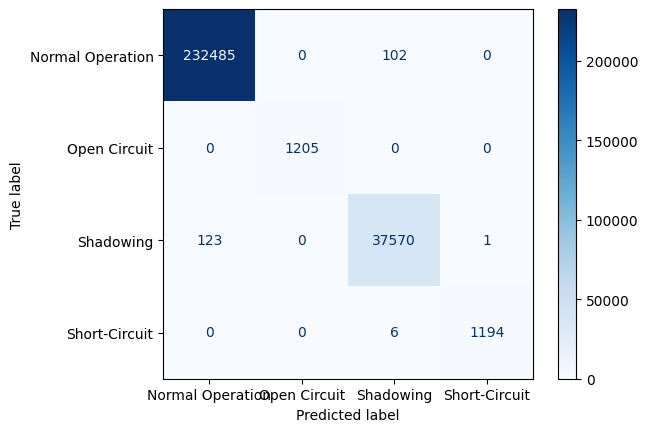

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Blues')

In [ ]:
X_test_sample = X_test[:100]

In [ ]:
# SHAP Interpretability
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_sample)

In [ ]:
# Summary plot
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, plot_type='bar')

In [ ]:
# Force plot for first sample
shap.initjs()
shap.force_plot(
    explainer.expected_value[0],
    shap_values[0][0],
    X_test.iloc[0],
    feature_names=X_test.columns
)

In [ ]:
# Save Model
joblib.dump(rf, 'rf_fault_detection_model.pkl')
joblib.dump(ohe, 'ohe_encoder.pkl')

In [ ]:
class BasePipeline(ABC):
    """
    Template method pattern: defines the skeleton of the ML pipeline
    """
    def __init__(self, X_train, y_train, X_test, y_test, class_weights=None):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.class_weights = class_weights
        self.model = None

    # Template method
    def run_pipeline(self):
        self.preprocess()
        self.build_model()
        self.train_model()
        self.evaluate_model()
        self.log_artifacts()

    # Steps that can be overridden or extended
    def preprocess(self):
        print("Default preprocessing")
        # override if necessary
        pass

    @abstractmethod
    def build_model(self):
        """Algorithm-specific model creation"""
        pass

    @abstractmethod
    def train_model(self):
        """Algorithm-specific training"""
        pass

    @abstractmethod
    def evaluate_model(self):
        """Algorithm-specific evaluation"""
        pass

    def log_artifacts(self):
        """Default MLflow logging"""
        mlflow.log_param("model_type", type(self.model).__name__)

In [ ]:
class ModelStrategy(ABC):
  @abstractmethod
  def build(self):
    pass


  @abstractmethod
  def train(self, X_train, y_train):
    pass


  @abstractmethod
  def evaluate(self, X_test, y_test):
    pass